In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
plt.rcParams['font.family']=['SimHei']
plt.rcParams['axes.unicode_minus']=False

In [2]:
path = 'sencond_cars_info.csv'
info = pd.read_csv(path, encoding = 'gbk')
info

,Brand,Name,Boarding_time,Km,Discharge,Sec_price,New_price
0,奥迪,奥迪A6L 2006款 2.4 CVT 舒适型,2006年8月,9.00万公里,国3,6.90,50.89万
1,奥迪,奥迪A6L 2007款 2.4 CVT 舒适型,2007年1月,8.00万公里,国4,8.88,50.89万
2,奥迪,奥迪A6L 2004款 2.4L 技术领先型,2005年5月,15.00万公里,国2,3.82,54.24万
3,奥迪,奥迪A8L 2013款 45 TFSI quattro舒适型,2013年10月,4.80万公里,欧4,44.80,101.06万
4,奥迪,奥迪A6L 2014款 30 FSI 豪华型,2014年9月,0.81万公里,"国4,国5",33.19,54.99万
...,...,...,...,...,...,...,...
11276,中华,中华V3 2016款 1.5L 自动 智能型,2016年6月,1.90万公里,"国4,国5",7.00,9.63万
11277,中华,骏捷FRV 2010款 1.3MT 舒适型,2011年6月,5.00万公里,国4,2.20,6.22万
11278,中华,骏捷 2007款 1.8 MT 豪华型,2007年10月,8.50万公里,国3,1.80,11.48万
11279,中华,骏捷FSV 2010款 1.5MT精英型,2011年12月,7.80万公里,国4,2.10,8.99万


In [3]:
info.shape

(11281, 7)

In [4]:
info.info

<bound method DataFrame.info of       Brand                            Name Boarding_time        Km Discharge  \
0        奥迪         奥迪A6L 2006款 2.4 CVT 舒适型       2006年8月   9.00万公里        国3   
1        奥迪         奥迪A6L 2007款 2.4 CVT 舒适型       2007年1月   8.00万公里        国4   
2        奥迪          奥迪A6L 2004款 2.4L 技术领先型       2005年5月  15.00万公里        国2   
3        奥迪  奥迪A8L 2013款 45 TFSI quattro舒适型      2013年10月   4.80万公里        欧4   
4        奥迪          奥迪A6L 2014款 30 FSI 豪华型       2014年9月   0.81万公里     国4,国5   
...     ...                             ...           ...       ...       ...   
11276    中华          中华V3 2016款 1.5L 自动 智能型       2016年6月   1.90万公里     国4,国5   
11277    中华           骏捷FRV 2010款 1.3MT 舒适型       2011年6月   5.00万公里        国4   
11278    中华             骏捷 2007款 1.8 MT 豪华型      2007年10月   8.50万公里        国3   
11279    中华            骏捷FSV 2010款 1.5MT精英型      2011年12月   7.80万公里        国4   
11280  中欧房车              尊逸 2013款 3.5L 尊逸A型       2014年4月   6.80万公里        欧4

In [5]:
info.columns

Index(['Brand', 'Name', 'Boarding_time', 'Km', 'Discharge', 'Sec_price',
       'New_price'],
      dtype='object')

In [6]:
info.Brand.value_counts().sort_values()

Brand
中欧房车       1
世爵         1
路特斯        1
腾势         1
WEY        1
        ... 
奥迪       758
宝马       773
奔驰       895
大众       991
别克      1350
Name: count, Length: 104, dtype: int64

In [7]:
info.Brand.count()

np.int64(11281)

In [8]:
#检查上牌时间中的脏数据
info[info.Boarding_time == "未上牌"]

,Brand,Name,Boarding_time,Km,Discharge,Sec_price,New_price
5,奥迪,奥迪R8 2014款 Spyder 5.2 FSI quattro,未上牌,0.03万公里,"国4,京5",169.00,273.86万
281,奥迪,奥迪RS 7 2016款 4.0T Sportback Performance,未上牌,0.20万公里,欧5,152.00,206.02万
449,奥迪,奥迪S5 2016款 Sportback 3.0T,未上牌,0.88万公里,"欧4,OBD",51.58,73.70万
569,奥迪,奥迪Q7 2016款 45 TFSI quattro S line 运动型,未上牌,百公里内,国5,79.98,98.76万
589,奥迪,奥迪RS 5 2012款 4.2L 双离合 quattro Coupe 特别版,未上牌,0.05万公里,"国4,国5",75.00,119.18万
...,...,...,...,...,...,...,...
8920,玛莎拉蒂,Ghibli 2017款 3.0T 标准型,未上牌,百公里内,欧5,78.00,98.89万
8961,玛莎拉蒂,Levante 2016款 3.0T 标准型,未上牌,0.10万公里,欧5,98.80,108.53万
8962,玛莎拉蒂,Levante 2016款 3.0T 标准型,未上牌,0.10万公里,欧5,98.80,108.53万
10101,特斯拉,MODEL X 2016款 90D,未上牌,0.05万公里,--,89.80,106.89万


In [9]:
#确定脏数据的占比：若比重小可删除
n = np.sum([info.Boarding_time == "未上牌"])
n / info.shape[0]

np.float64(0.00824395000443223)

In [10]:
#利用索引drop删除或者直接赋值
info = info[info.Boarding_time != "未上牌"]
info

,Brand,Name,Boarding_time,Km,Discharge,Sec_price,New_price
0,奥迪,奥迪A6L 2006款 2.4 CVT 舒适型,2006年8月,9.00万公里,国3,6.90,50.89万
1,奥迪,奥迪A6L 2007款 2.4 CVT 舒适型,2007年1月,8.00万公里,国4,8.88,50.89万
2,奥迪,奥迪A6L 2004款 2.4L 技术领先型,2005年5月,15.00万公里,国2,3.82,54.24万
3,奥迪,奥迪A8L 2013款 45 TFSI quattro舒适型,2013年10月,4.80万公里,欧4,44.80,101.06万
4,奥迪,奥迪A6L 2014款 30 FSI 豪华型,2014年9月,0.81万公里,"国4,国5",33.19,54.99万
...,...,...,...,...,...,...,...
11276,中华,中华V3 2016款 1.5L 自动 智能型,2016年6月,1.90万公里,"国4,国5",7.00,9.63万
11277,中华,骏捷FRV 2010款 1.3MT 舒适型,2011年6月,5.00万公里,国4,2.20,6.22万
11278,中华,骏捷 2007款 1.8 MT 豪华型,2007年10月,8.50万公里,国3,1.80,11.48万
11279,中华,骏捷FSV 2010款 1.5MT精英型,2011年12月,7.80万公里,国4,2.10,8.99万


In [11]:
#删除后索引混乱，可重新赋值
info.index = np.arange(0,info.shape[0])
info

,Brand,Name,Boarding_time,Km,Discharge,Sec_price,New_price
0,奥迪,奥迪A6L 2006款 2.4 CVT 舒适型,2006年8月,9.00万公里,国3,6.90,50.89万
1,奥迪,奥迪A6L 2007款 2.4 CVT 舒适型,2007年1月,8.00万公里,国4,8.88,50.89万
2,奥迪,奥迪A6L 2004款 2.4L 技术领先型,2005年5月,15.00万公里,国2,3.82,54.24万
3,奥迪,奥迪A8L 2013款 45 TFSI quattro舒适型,2013年10月,4.80万公里,欧4,44.80,101.06万
4,奥迪,奥迪A6L 2014款 30 FSI 豪华型,2014年9月,0.81万公里,"国4,国5",33.19,54.99万
...,...,...,...,...,...,...,...
11183,中华,中华V3 2016款 1.5L 自动 智能型,2016年6月,1.90万公里,"国4,国5",7.00,9.63万
11184,中华,骏捷FRV 2010款 1.3MT 舒适型,2011年6月,5.00万公里,国4,2.20,6.22万
11185,中华,骏捷 2007款 1.8 MT 豪华型,2007年10月,8.50万公里,国3,1.80,11.48万
11186,中华,骏捷FSV 2010款 1.5MT精英型,2011年12月,7.80万公里,国4,2.10,8.99万


In [12]:
#通过切片提取上牌时间中的年份和月份
info.loc[:,"year"] = info.Boarding_time.str[:4].astype("int")
info.loc[:,"month"] = info.Boarding_time.str[5:-1].astype("int")
info

C:\Users\ZPth\AppData\Local\Temp\ipykernel_22280\3555892233.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info.loc[:,"year"] = info.Boarding_time.str[:4].astype("int")
C:\Users\ZPth\AppData\Local\Temp\ipykernel_22280\3555892233.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info.loc[:,"month"] = info.Boarding_time.str[5:-1].astype("int")


,Brand,Name,Boarding_time,Km,Discharge,Sec_price,New_price,year,month
0,奥迪,奥迪A6L 2006款 2.4 CVT 舒适型,2006年8月,9.00万公里,国3,6.90,50.89万,2006,8
1,奥迪,奥迪A6L 2007款 2.4 CVT 舒适型,2007年1月,8.00万公里,国4,8.88,50.89万,2007,1
2,奥迪,奥迪A6L 2004款 2.4L 技术领先型,2005年5月,15.00万公里,国2,3.82,54.24万,2005,5
3,奥迪,奥迪A8L 2013款 45 TFSI quattro舒适型,2013年10月,4.80万公里,欧4,44.80,101.06万,2013,10
4,奥迪,奥迪A6L 2014款 30 FSI 豪华型,2014年9月,0.81万公里,"国4,国5",33.19,54.99万,2014,9
...,...,...,...,...,...,...,...,...,...
11183,中华,中华V3 2016款 1.5L 自动 智能型,2016年6月,1.90万公里,"国4,国5",7.00,9.63万,2016,6
11184,中华,骏捷FRV 2010款 1.3MT 舒适型,2011年6月,5.00万公里,国4,2.20,6.22万,2011,6
11185,中华,骏捷 2007款 1.8 MT 豪华型,2007年10月,8.50万公里,国3,1.80,11.48万,2007,10
11186,中华,骏捷FSV 2010款 1.5MT精英型,2011年12月,7.80万公里,国4,2.10,8.99万,2011,12


In [13]:
#若当前数据集是在2017年10月统计的，新增一列存放使用月份
info.loc[:,"Use_time"] = (2017-info.year)*12 + 10 - info.month
info

C:\Users\ZPth\AppData\Local\Temp\ipykernel_22280\3568181955.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info.loc[:,"Use_time"] = (2017-info.year)*12 + 10 - info.month


,Brand,Name,Boarding_time,Km,Discharge,Sec_price,New_price,year,month,Use_time
0,奥迪,奥迪A6L 2006款 2.4 CVT 舒适型,2006年8月,9.00万公里,国3,6.90,50.89万,2006,8,134
1,奥迪,奥迪A6L 2007款 2.4 CVT 舒适型,2007年1月,8.00万公里,国4,8.88,50.89万,2007,1,129
2,奥迪,奥迪A6L 2004款 2.4L 技术领先型,2005年5月,15.00万公里,国2,3.82,54.24万,2005,5,149
3,奥迪,奥迪A8L 2013款 45 TFSI quattro舒适型,2013年10月,4.80万公里,欧4,44.80,101.06万,2013,10,48
4,奥迪,奥迪A6L 2014款 30 FSI 豪华型,2014年9月,0.81万公里,"国4,国5",33.19,54.99万,2014,9,37
...,...,...,...,...,...,...,...,...,...,...
11183,中华,中华V3 2016款 1.5L 自动 智能型,2016年6月,1.90万公里,"国4,国5",7.00,9.63万,2016,6,16
11184,中华,骏捷FRV 2010款 1.3MT 舒适型,2011年6月,5.00万公里,国4,2.20,6.22万,2011,6,76
11185,中华,骏捷 2007款 1.8 MT 豪华型,2007年10月,8.50万公里,国3,1.80,11.48万,2007,10,120
11186,中华,骏捷FSV 2010款 1.5MT精英型,2011年12月,7.80万公里,国4,2.10,8.99万,2011,12,70


In [14]:
#处理Km列
#将字符串转化为可处理的浮点数据，产生报错————有脏数据待处理
#通过索引加切片得到干净数据（利用contains函数）
info = info[~info.Km.str.contains("百")]
info.loc[:,"New_Km"] = info.Km.str[:-3].astype("float")
info

C:\Users\ZPth\AppData\Local\Temp\ipykernel_22280\2744507739.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info.loc[:,"New_Km"] = info.Km.str[:-3].astype("float")


,Brand,Name,Boarding_time,Km,Discharge,Sec_price,New_price,year,month,Use_time,New_Km
0,奥迪,奥迪A6L 2006款 2.4 CVT 舒适型,2006年8月,9.00万公里,国3,6.90,50.89万,2006,8,134,9.00
1,奥迪,奥迪A6L 2007款 2.4 CVT 舒适型,2007年1月,8.00万公里,国4,8.88,50.89万,2007,1,129,8.00
2,奥迪,奥迪A6L 2004款 2.4L 技术领先型,2005年5月,15.00万公里,国2,3.82,54.24万,2005,5,149,15.00
3,奥迪,奥迪A8L 2013款 45 TFSI quattro舒适型,2013年10月,4.80万公里,欧4,44.80,101.06万,2013,10,48,4.80
4,奥迪,奥迪A6L 2014款 30 FSI 豪华型,2014年9月,0.81万公里,"国4,国5",33.19,54.99万,2014,9,37,0.81
...,...,...,...,...,...,...,...,...,...,...,...
11183,中华,中华V3 2016款 1.5L 自动 智能型,2016年6月,1.90万公里,"国4,国5",7.00,9.63万,2016,6,16,1.90
11184,中华,骏捷FRV 2010款 1.3MT 舒适型,2011年6月,5.00万公里,国4,2.20,6.22万,2011,6,76,5.00
11185,中华,骏捷 2007款 1.8 MT 豪华型,2007年10月,8.50万公里,国3,1.80,11.48万,2007,10,120,8.50
11186,中华,骏捷FSV 2010款 1.5MT精英型,2011年12月,7.80万公里,国4,2.10,8.99万,2011,12,70,7.80


In [15]:
#处理New_price列数据
#转换过程仍发现脏数据需要处理
info = info[~info.New_price.str.contains("暂")]
info.loc[:,"New_New_price"] = info.New_price.str[:-1].astype("float")
info

C:\Users\ZPth\AppData\Local\Temp\ipykernel_22280\2644530682.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info.loc[:,"New_New_price"] = info.New_price.str[:-1].astype("float")


,Brand,Name,Boarding_time,Km,Discharge,Sec_price,New_price,year,month,Use_time,New_Km,New_New_price
0,奥迪,奥迪A6L 2006款 2.4 CVT 舒适型,2006年8月,9.00万公里,国3,6.90,50.89万,2006,8,134,9.00,50.89
1,奥迪,奥迪A6L 2007款 2.4 CVT 舒适型,2007年1月,8.00万公里,国4,8.88,50.89万,2007,1,129,8.00,50.89
2,奥迪,奥迪A6L 2004款 2.4L 技术领先型,2005年5月,15.00万公里,国2,3.82,54.24万,2005,5,149,15.00,54.24
3,奥迪,奥迪A8L 2013款 45 TFSI quattro舒适型,2013年10月,4.80万公里,欧4,44.80,101.06万,2013,10,48,4.80,101.06
4,奥迪,奥迪A6L 2014款 30 FSI 豪华型,2014年9月,0.81万公里,"国4,国5",33.19,54.99万,2014,9,37,0.81,54.99
...,...,...,...,...,...,...,...,...,...,...,...,...
11183,中华,中华V3 2016款 1.5L 自动 智能型,2016年6月,1.90万公里,"国4,国5",7.00,9.63万,2016,6,16,1.90,9.63
11184,中华,骏捷FRV 2010款 1.3MT 舒适型,2011年6月,5.00万公里,国4,2.20,6.22万,2011,6,76,5.00,6.22
11185,中华,骏捷 2007款 1.8 MT 豪华型,2007年10月,8.50万公里,国3,1.80,11.48万,2007,10,120,8.50,11.48
11186,中华,骏捷FSV 2010款 1.5MT精英型,2011年12月,7.80万公里,国4,2.10,8.99万,2011,12,70,7.80,8.99


In [16]:
#查看不同价格区间的二手车数量及占比
info.Sec_price.value_counts()

Sec_price
4.50     91
4.80     83
8.80     79
5.50     75
4.88     72
         ..
5.19      1
24.51     1
18.86     1
11.23     1
4.06      1
Name: count, Length: 1899, dtype: int64

In [17]:
#找出区间上限与下限
info.Sec_price.sort_values()
price_max = 1000
price_min = 0
price_bins = [price_min, 3, 5, 8, 10, 15, 20, 30, 50, 100, price_max]

In [18]:
#利用pandas的cut函数完成对区间的划分
price_cut = pd.cut(info.Sec_price, bins = price_bins)
price_result = price_cut.value_counts().sort_index()
price_result

Sec_price
(0, 3]          813
(3, 5]         1790
(5, 8]         1956
(8, 10]         914
(10, 15]       1307
(15, 20]        979
(20, 30]       1090
(30, 50]        957
(50, 100]       710
(100, 1000]     468
Name: count, dtype: int64

In [19]:
#利用列表表达式得到不同区间的占比情况（列表形式）
L = []
for i in range(10):
    L.append(i)
print(L)

[i for i in range(5)]

price_percent = [str(round(i,2)) + "%" for i in price_result / price_result.sum() * 100]
price_percent

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


['7.4%',
 '16.3%',
 '17.81%',
 '8.32%',
 '11.9%',
 '8.91%',
 '9.92%',
 '8.71%',
 '6.46%',
 '4.26%']

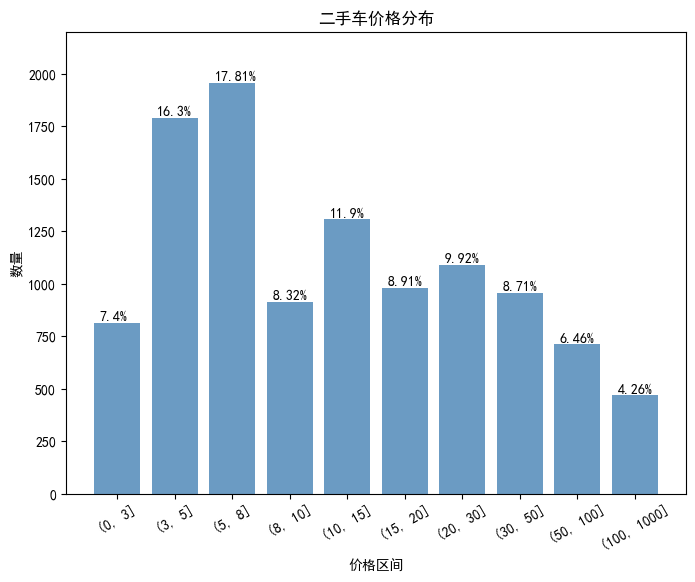

In [20]:
#画柱状图以及饼状图
def fun1():
    x = np.arange(len(price_result))
    y = price_result
    plt.figure(figsize = (8,6))
    plt.bar(x,y,color = "steelblue",alpha = 0.8)
    plt.xlabel("价格区间")
    plt.ylabel("数量")
    plt.title("二手车价格分布")
    plt.xticks(np.arange(len(price_result)), price_result.index, rotation = 30)
    plt.ylim([0,2200])

    for a,b,c in zip(x-0.3,y+10,price_percent):
        plt.text(a,b,c)
fun1()

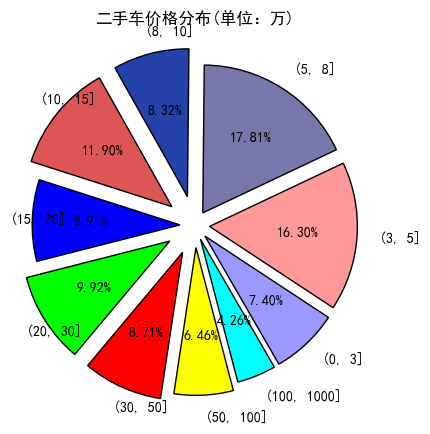

In [21]:
def fun2():
    L = [i for i in price_result / price_result.sum()]#占比情况

    labels = price_result.index#区间
    
    colors=["#9999ff","#ff9999","#7777aa","#2442aa","#dd5555","#0000ff","#00ff00","#ff0000","#ffff00","#00ffff"]#颜色
    
    explode = [0.1,0.1,0.1,0.2,0.2,0.1,0.2,0.2,0.15,0.1]#板块分离度
    
    plt.pie(x=L, #绘图数据
        labels=labels, #数据标签 
        colors=colors, #饼图颜色
        autopct="%.2f%%", #设置百分比，小数点后保留2位
        startangle=300, #设置图的初始角度
        pctdistance = 0.6, #百分比数字距离圆心的远近
        labeldistance = 1.15, #标签距离数字的远近
        frame=0, #是否显示边框
        center=(2,2), #设置饼图原点
        explode=explode, #设置突出显示
        radius=1, #设置饼的半径
        textprops = {"fontsize":10}, #全局字体大小设置
        wedgeprops = {"edgecolor":"black", "linewidth":1}) #扇区间分割线
    
    plt.title("二手车价格分布(单位：万)",fontsize = 12,pad = 12)
fun2()

In [33]:
#绘制散点图，描述二手车价格，行驶里程，使用时长之间的关系（选取奥迪和大众两个品牌）
#抽取大众与奥迪的数据
index = info.Brand.isin(["奥迪","大众"])
part = info.loc[index,["Brand","Sec_price","Use_time","New_Km"]]
part

,Brand,Sec_price,Use_time,New_Km
0,奥迪,6.90,134,9.00
1,奥迪,8.88,129,8.00
2,奥迪,3.82,149,15.00
3,奥迪,44.80,48,4.80
4,奥迪,33.19,37,0.81
...,...,...,...,...
5833,大众,7.78,89,7.84
5834,大众,0.65,58,18.00
5835,大众,0.98,58,23.00
5836,大众,0.96,46,16.00


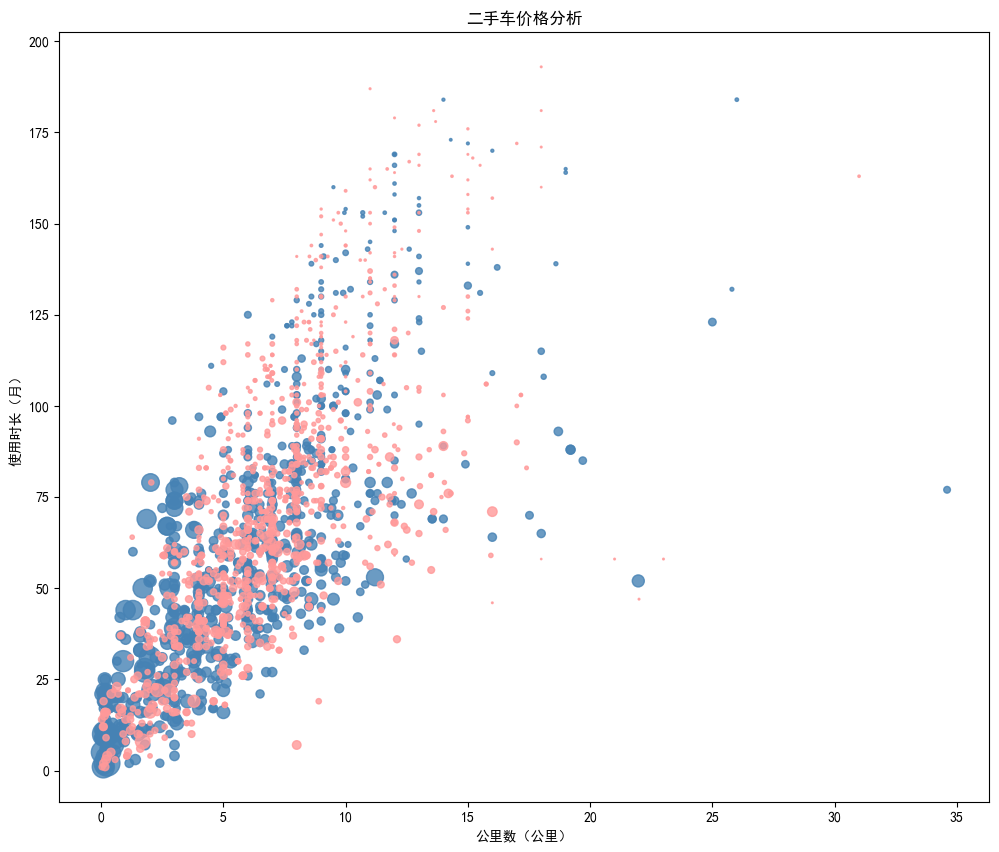

In [36]:
def fun2():
    Brands = ["奥迪","大众"]
    colors =["steelblue","#ff9999"]
    plt.figure(figsize=(12,10))
    for i in range(2):
        plt.scatter(part[part.Brand == Brands[i]].New_Km,
                    part[part.Brand == Brands[i]].Use_time,
                    s = (part[part.Brand == Brands[i]].Sec_price)*1.5,
                    c = colors[i],
                    alpha = 0.8)
    plt.xlabel("公里数（公里）")
    plt.ylabel("使用时长（月）")
    plt.title("二手车价格分析")
fun2()

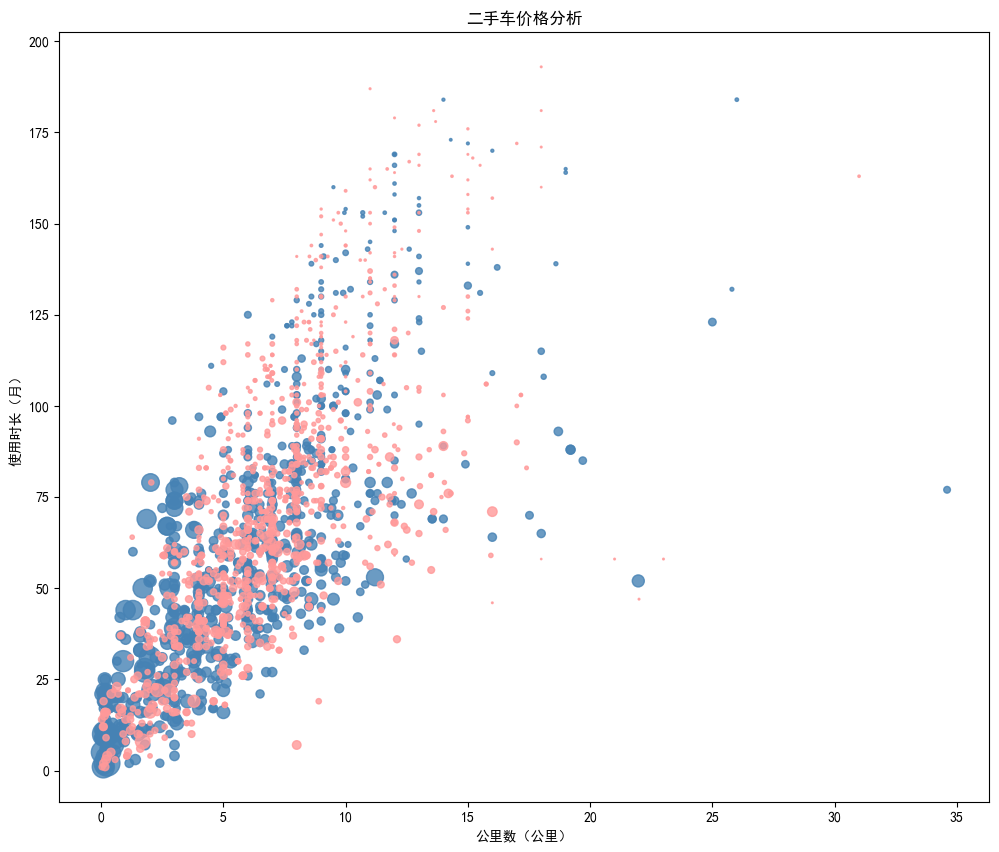

In [41]:
fun2()
plt.savefig("scatter.jpg",dpi = 1000, bbox_inches = "tight")